# Task-1

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Draw a list of 2D vectors as arrows from the origin.
def draw_vectors(vectors, labels, title="2D Vectors"):
    fig, ax = plt.subplots(figsize=(6, 6))

    for v, label in zip(vectors, labels):

        ax.quiver(
            0, 0,
            v[0], v[1],
            angles='xy',
            scale_units='xy',
            scale=1
        )

        ax.text(v[0], v[1], label, fontsize=12)

    # Keep x and y scales equal
    ax.set_aspect('equal')

    # Add grid and coordinate axes
    ax.grid(alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    # Set plot limits automatically
    all_values = np.array(vectors)
    limit = np.max(np.abs(all_values)) + 2

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title)

    plt.show()

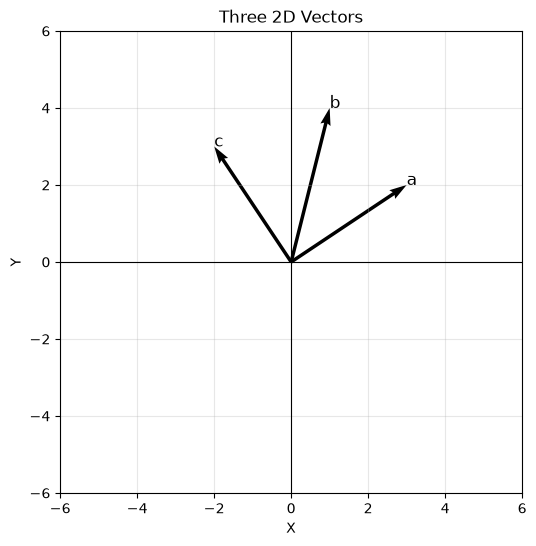

In [6]:
#Three vectors
a = np.array([3, 2])
b = np.array([1, 4])
c = np.array([-2, 3])

draw_vectors(
    [a, b, c],
    ["a", "b", "c"],
    "Three 2D Vectors"
)

In [ ]:
#Vector addition 
a_plus_b = a + b

print("a =", a)
print("b =", b)
print("a + b =", a_plus_b)

a = [3 2]
b = [1 4]
a + b = [4 6]


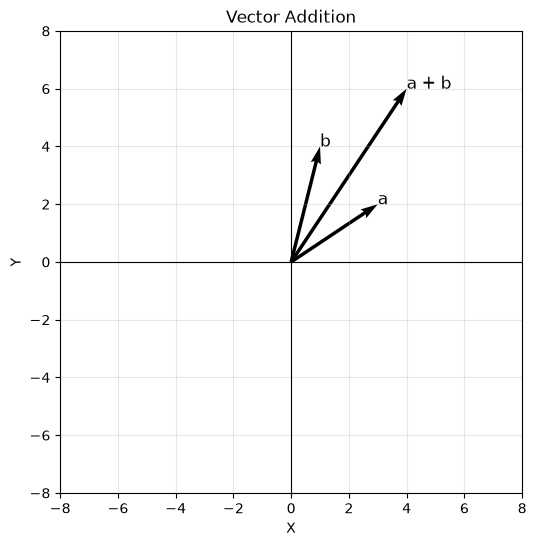

In [ ]:
#draw vectors for a, b, and a + b
draw_vectors(
    [a, b, a_plus_b],
    ["a", "b", "a + b"],
    "Vector Addition"
)


In [9]:
#Vector scaling 
two_a = 2 * a
negative_a = -a

print("\na =", a)
print("2a =", two_a)
print("-a =", negative_a)


a = [3 2]
2a = [6 4]
-a = [-3 -2]


In [10]:
# Positive scaling changes the length but keeps the direction.
# Negative scaling reverses the direction.
# 2a is twice as long as a.
# -a has the same length as a but points in the opposite direction.

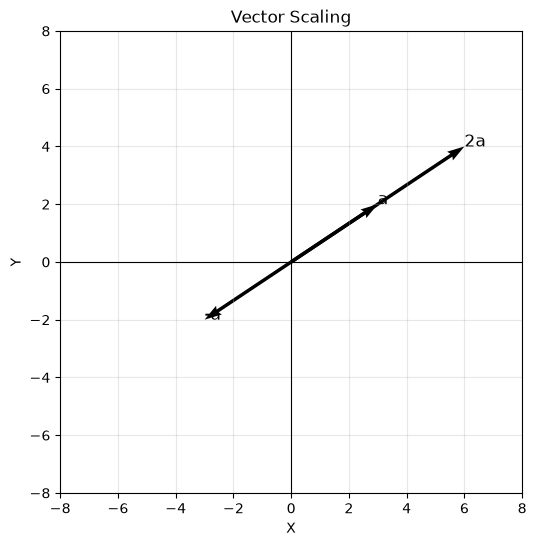

In [11]:
#draw a scaled vector, a scaled vector, and a negative vector
draw_vectors(
    [a, two_a, negative_a],
    ["a", "2a", "-a"],
    "Vector Scaling"
)


In [12]:
#Vector subtraction
a_minus_b = a - b

print("\na =", a)
print("b =", b)
print("a - b =", a_minus_b)


a = [3 2]
b = [1 4]
a - b = [ 2 -2]


In [13]:
# a - b represents the displacement from b to a.
# Therefore, a - b points from b to a.
# Displacement = final position - starting position.

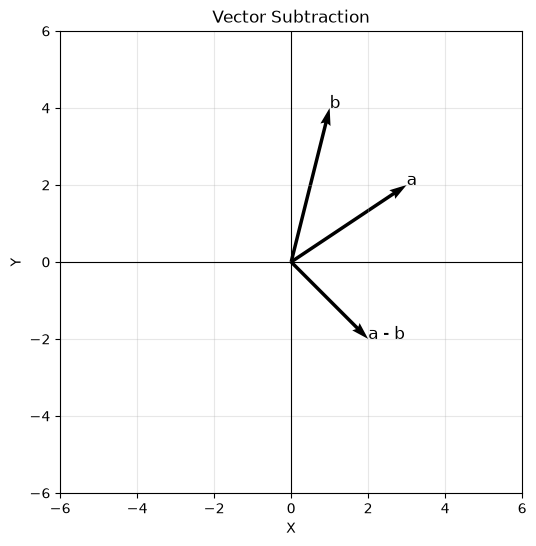

In [14]:
#draw a vector for a, b, and a - b
draw_vectors(
    [a, b, a_minus_b],
    ["a", "b", "a - b"],
    "Vector Subtraction"
)

# Task-2

In [15]:
#Calculate the angle between two vectors in degrees.
def angle_between(a, b):
    cos_theta = (a @ b) / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )
    cos_theta = np.clip(cos_theta, -1, 1)
    return np.degrees(np.arccos(cos_theta))
# Mathematically cosine must be between -1 and 1.


In [16]:
#Perpendicular vectors
#Expected angle = 90 degrees
a = np.array([1, 0])
b = np.array([0, 1])

print("Perpendicular:", angle_between(a, b), "degrees")

Perpendicular: 90.0 degrees


In [17]:
#Identical vectors
#Expected angle = 0 degrees
a = np.array([1, 2])
b = np.array([1, 2])

print("Identical:", angle_between(a, b), "degrees")

Identical: 1.2074182697257333e-06 degrees


In [18]:
#Opposite vectors
#Expected angle = 180 degrees
a = np.array([1, 0])
b = np.array([-1, 0])

print("Opposite:", angle_between(a, b), "degrees")

Opposite: 180.0 degrees


In [19]:
#Exam-score vectors
student_a = np.array([90, 85, 80, 95])
student_b = np.array([88, 82, 78, 92])

student_angle = angle_between(student_a, student_b)

print("\nAngle between student score vectors:",
      student_angle, "degrees")

# A small angle means the students have similar
# performance patterns across the subjects.


Angle between student score vectors: 0.30389265123178844 degrees


In [20]:
#Scaling test
a = np.array([3, 4])
b = np.array([4, 1])

angle1 = angle_between(a, b)
angle2 = angle_between(a, 5 * b)

print("\nAngle(a, b):", angle1)
print("Angle(a, 5b):", angle2)

# Scaling b by 5 changes its length but not its direction.
# Therefore, the angle remains unchanged.


Angle(a, b): 39.0938588862295
Angle(a, 5b): 39.0938588862295


# Task-3(Gram-Schmidt Orthogonalisation)

In [21]:
#Convert input vectors into an orthonormal basis.
def gram_schmidt(vectors):
    basis = []
    for v in vectors:

        w = v.astype(float).copy()
        for b in basis:

            projection = (v @ b) * b
            w = w - projection

        norm = np.linalg.norm(w)

        if norm > 1e-10:
            basis.append(w / norm)
    return np.array(basis)

In [22]:
#Three independent 3D vectors
v1 = np.array([1, 1, 0])
v2 = np.array([1, 0, 1])
v3 = np.array([0, 1, 1])

vectors = np.array([v1, v2, v3])

print("Input vectors:")
print(vectors)


# Apply Gram-Schmidt
Q = gram_schmidt(vectors)

print("\nOrthonormal basis:")
print(Q)

Input vectors:
[[1 1 0]
 [1 0 1]
 [0 1 1]]

Orthonormal basis:
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]


In [23]:
#Prove orthonormality
identity_check = Q @ Q.T

print("\nQ @ Q.T:")
print(identity_check)


Q @ Q.T:
[[ 1.00000000e+00  1.03018891e-16  1.51811967e-16]
 [ 1.03018891e-16  1.00000000e+00 -1.59104334e-16]
 [ 1.51811967e-16 -1.59104334e-16  1.00000000e+00]]


In [24]:
#Q @ Q.T should be approximately the identity matrix.
#
# Diagonal = 1
#   -> each vector has length 1
#
# Off-diagonal = 0
#   -> vectors are perpendicular
#
# Therefore, Q is an orthonormal basis.

In [25]:
#Check rank
input_rank = np.linalg.matrix_rank(vectors)
output_rank = np.linalg.matrix_rank(Q)

print("\nInput rank:", input_rank)
print("Output rank:", output_rank)


Input rank: 3
Output rank: 3


In [26]:
# The ranks should be equal.
# This shows that Gram-Schmidt preserves the
# number of independent directions.

In [27]:
#Dependent vectors
v1 = np.array([1, 0, 1])
v2 = np.array([0, 1, 1])

# v3 is dependent because it is v1 + v2
v3 = v1 + v2

dependent_vectors = np.array([v1, v2, v3])

print("\nDependent vectors:")
print(dependent_vectors)


Q_dependent = gram_schmidt(dependent_vectors)

print("\nBasis from dependent vectors:")
print(Q_dependent)

print("Number of basis vectors:", len(Q_dependent))


Dependent vectors:
[[1 0 1]
 [0 1 1]
 [1 1 2]]

Basis from dependent vectors:
[[ 0.70710678  0.          0.70710678]
 [-0.40824829  0.81649658  0.40824829]]
Number of basis vectors: 2


In [28]:
# The third vector is dependent on the first two,
# so Gram-Schmidt ignores the near-zero vector.
# Therefore, only two independent basis vectors remain.

In [29]:
#Compare with NumPy QR
Q_numpy, R = np.linalg.qr(vectors)

print("\nOur Gram-Schmidt Q:")
print(Q)

print("\nNumPy QR Q:")
print(Q_numpy)


Our Gram-Schmidt Q:
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

NumPy QR Q:
[[-0.70710678  0.40824829 -0.57735027]
 [-0.70710678 -0.40824829  0.57735027]
 [-0.          0.81649658  0.57735027]]


In [30]:
# The two bases may differ by signs.
# v and -v represent the same direction,
# so a sign difference is not a real mathematical difference.

# Task-4

In [31]:
#Generate many vector pairs
angles = []
dots = []

# Fixed vector
base = np.array([1.0, 0.0])

# Generate vectors from 0° to 180°
for deg in range(0, 181, 5):

    # Convert degrees to radians
    rad = np.radians(deg)

    # Unit vector at the selected angle
    v = np.array([
        np.cos(rad),
        np.sin(rad)
    ])

    # Store angle and dot product
    angles.append(deg)
    dots.append(base @ v)

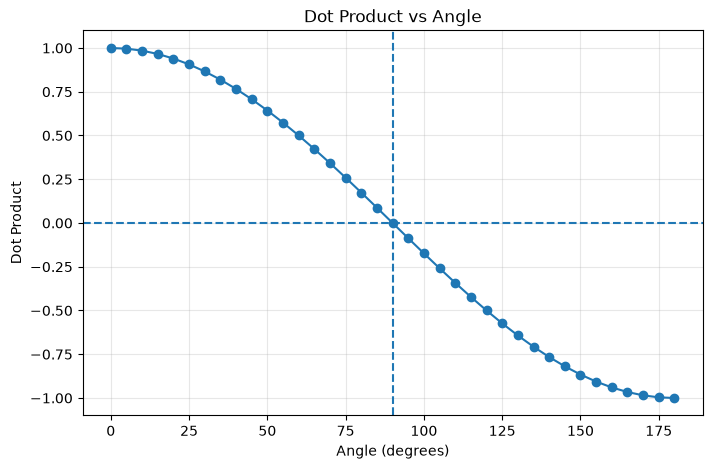

In [32]:
#Plot dot product vs angle
plt.figure(figsize=(8, 5))

plt.plot(angles, dots, marker='o')

# Dot product = 0 line
plt.axhline(0, linestyle='--')

# 90 degree line
plt.axvline(90, linestyle='--')

plt.xlabel("Angle (degrees)")
plt.ylabel("Dot Product")
plt.title("Dot Product vs Angle")

plt.grid(alpha=0.3)
plt.show()

In [33]:
#Verify 90 degree case
v_90 = np.array([
    np.cos(np.radians(90)),
    np.sin(np.radians(90))
])

dot_90 = base @ v_90

print("Dot product at 90°:", dot_90)
print("Is it approximately zero?", np.isclose(dot_90, 0))

Dot product at 90°: 6.123233995736766e-17
Is it approximately zero? True


In [34]:
#Three specific examples
# Perpendicular
a1 = np.array([1.0, 0.0])
b1 = np.array([0.0, 1.0])

# 45 degrees
a2 = np.array([1.0, 0.0])
b2 = np.array([1.0, 1.0])

# Nearly parallel
a3 = np.array([1.0, 0.0])
b3 = np.array([1.0, 0.1])


# Print dot products
print("\nPerpendicular dot product:", a1 @ b1)
print("45° dot product:", a2 @ b2)
print("Nearly parallel dot product:", a3 @ b3)


Perpendicular dot product: 0.0
45° dot product: 1.0
Nearly parallel dot product: 1.0


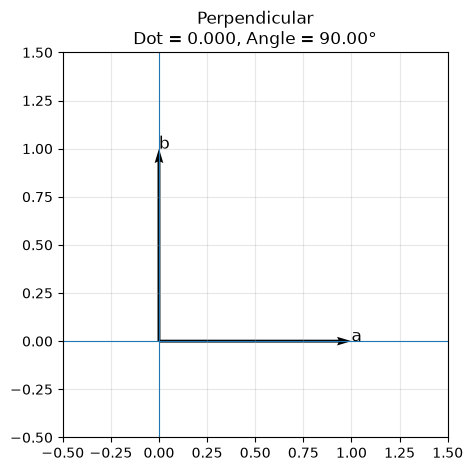

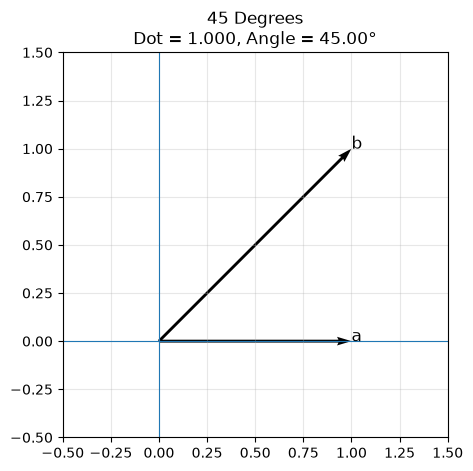

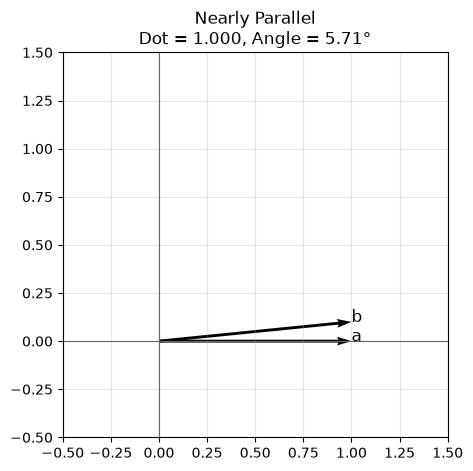

In [35]:
#Helper function to draw vector pairs
def draw_pair(a, b, title):

    fig, ax = plt.subplots(figsize=(5, 5))

    # Draw vector a
    ax.quiver(
        0, 0, a[0], a[1],
        angles='xy',
        scale_units='xy',
        scale=1
    )

    # Draw vector b
    ax.quiver(
        0, 0, b[0], b[1],
        angles='xy',
        scale_units='xy',
        scale=1
    )

    # Calculate dot product
    dot = a @ b

    # Calculate angle
    cos_theta = dot / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )

    cos_theta = np.clip(cos_theta, -1, 1)

    angle = np.degrees(np.arccos(cos_theta))

    # Labels
    ax.text(a[0], a[1], "a", fontsize=12)
    ax.text(b[0], b[1], "b", fontsize=12)

    # Show dot product and angle
    ax.set_title(
        f"{title}\n"
        f"Dot = {dot:.3f}, Angle = {angle:.2f}°"
    )

    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    plt.show()


# Draw all three examples
draw_pair(a1, b1, "Perpendicular")
draw_pair(a2, b2, "45 Degrees")
draw_pair(a3, b3, "Nearly Parallel")

In [36]:
#Key mathematical proof
# a · b = |a||b|cos(theta)
#
# If a · b = 0 and both vectors are non-zero:
#
# cos(theta) = 0
#
# Therefore:
#
# theta = 90°
#
# So a zero dot product means the vectors are perpendicular.


# Task-5

In [38]:
# Vocabulary
vocab = ['ml', 'data', 'model', 'cook', 'recipe', 'food']

print("Vocabulary:")
print(vocab)


Vocabulary:
['ml', 'data', 'model', 'cook', 'recipe', 'food']


In [39]:
#Documents as word-count vectors
docs = np.array([
    [8, 6, 4, 0, 0, 1],   # Document 1 - ML
    [0, 1, 0, 7, 8, 6],   # Document 2 - Cooking
    [7, 5, 5, 0, 1, 0],   # Document 3 - ML
    [1, 2, 1, 6, 7, 5],   # Document 4 - Cooking
    [6, 7, 4, 0, 0, 0]    # Document 5 - ML
])

print("\nDocuments:")
print(docs)


Documents:
[[8 6 4 0 0 1]
 [0 1 0 7 8 6]
 [7 5 5 0 1 0]
 [1 2 1 6 7 5]
 [6 7 4 0 0 0]]


In [40]:
#Search query
query = np.array([9, 7, 5, 0, 0, 0])

print("\nQuery:")
print(query)


Query:
[9 7 5 0 0 0]


In [41]:
#Cosine similarity
def cosine_similarity(a, b):
    # Calculate dot product
    dot_product = a @ b

    # Calculate vector lengths
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    # Calculate cosine similarity
    return dot_product / (norm_a * norm_b)


In [43]:
#Search function
def search(query, documents):
    similarities = np.array([
        cosine_similarity(query, doc)
        for doc in documents
    ])

    # Sort from highest similarity to lowest
    ranking = np.argsort(similarities)[::-1]

    return ranking, similarities

In [45]:
#Rank documents
ranking, similarities = search(query, docs)

print("\nSearch Results:")

for rank, index in enumerate(ranking, start=1):

    print(
        f"{rank}. Document {index + 1} "
        f"(cosine similarity = {similarities[index]:.3f})"
    )


Search Results:
1. Document 1 (cosine similarity = 0.995)
2. Document 3 (cosine similarity = 0.988)
3. Document 5 (cosine similarity = 0.983)
4. Document 4 (cosine similarity = 0.209)
5. Document 2 (cosine similarity = 0.046)


In [46]:
#Different-topic document
different_topic = np.array([
    20, 15, 0, 10, 5, 8
])

docs_extended = np.vstack([
    docs,
    different_topic
])

ranking, similarities = search(query, docs_extended)

print("\nRanking with different-topic document:")

for rank, index in enumerate(ranking, start=1):

    print(
        f"{rank}. Document {index + 1} "
        f"(cosine similarity = {similarities[index]:.3f})"
    )


Ranking with different-topic document:
1. Document 1 (cosine similarity = 0.995)
2. Document 3 (cosine similarity = 0.988)
3. Document 5 (cosine similarity = 0.983)
4. Document 6 (cosine similarity = 0.802)
5. Document 4 (cosine similarity = 0.209)
6. Document 2 (cosine similarity = 0.046)


In [47]:
# Cosine similarity compares vector direction.
# It does not understand the actual meaning of words.
# Therefore, a document can share many words with a query
# but still be about a different topic.


In [48]:
#Different document lengths
doc_small = np.array([2, 3, 1, 0, 0, 0])

# Same topic but 5 times larger
doc_large = 5 * doc_small

print("\nSmall document:")
print(doc_small)

print("\nLarge document:")
print(doc_large)


# Compare cosine similarity
print(
    "\nCosine similarity between small and large:",
    cosine_similarity(doc_small, doc_large)
)



Small document:
[2 3 1 0 0 0]

Large document:
[10 15  5  0  0  0]

Cosine similarity between small and large: 1.0


In [49]:
# The result should be 1.0 because both vectors
# point in exactly the same direction.

In [50]:
#Compare raw dot product
small_dot = query @ doc_small
large_dot = query @ doc_large

small_cosine = cosine_similarity(query, doc_small)
large_cosine = cosine_similarity(query, doc_large)

print("\nSmall document:")
print("Dot product:", small_dot)
print("Cosine similarity:", small_cosine)

print("\nLarge document:")
print("Dot product:", large_dot)
print("Cosine similarity:", large_cosine)


Small document:
Dot product: 44
Cosine similarity: 0.9445453396304021

Large document:
Dot product: 220
Cosine similarity: 0.944545339630402


In [51]:
# Raw dot product increases with document length.
# A longer document can therefore receive a higher score
# even when its topic/direction is the same.
#
# Cosine similarity normalises the vectors and focuses
# on their direction instead of their magnitude.

In [52]:
#Cosine of a vector with itself
doc = np.array([4, 2, 7, 0, 1, 3])

print(
    "\nCosine similarity of document with itself:",
    cosine_similarity(doc, doc)
)


Cosine similarity of document with itself: 1.0


In [53]:
# A vector has angle 0° with itself.
# cos(0°) = 1.
# Therefore, its cosine similarity with itself is 1.